# Malaysia Regression and Data Visualization

This notebook examines Malaysia Sample by conducting regression analyses to explore the relationship between variables and using data visualization to represent data pattern in the sample

In [4]:
import pandas as pd

my1 = pd.read_csv("../data/processed/malaysia_cleaned.csv")

In [5]:
ls ../data/processed

malaysia_cleaned.csv        malaysia_part_b_sutong.csv
malaysia_part_a_jianru.csv


In [6]:
print(my1.columns)

Index(['D_INTERVIEW', 'edu', 'household_income', 'em', 'marriage',
       'victim_self', 'victim_family', 'Q131_cat', 'Q138_cat', 'gender_cat',
       'Q262'],
      dtype='str')


In [7]:
my1.head(20)

,D_INTERVIEW,edu,household_income,em,marriage,victim_self,victim_family,Q131_cat,Q138_cat,gender_cat,Q262
0,458070001.0,2.0,2.0,0,0,0,1,2,4,2,18.0
1,458070002.0,0.0,3.0,1,0,0,0,2,4,1,19.0
2,458070003.0,2.0,3.0,1,1,0,0,2,4,1,49.0
3,458070004.0,2.0,5.0,1,1,0,0,4,3,2,47.0
4,458070005.0,6.0,4.0,1,1,0,0,2,3,2,38.0
5,458070006.0,2.0,4.0,1,1,0,0,3,2,1,44.0
6,458070007.0,2.0,3.0,1,0,0,0,2,2,1,25.0
7,458070008.0,2.0,4.0,0,1,0,0,2,4,2,66.0
8,458070009.0,2.0,5.0,1,1,0,0,1,4,1,41.0
9,458070010.0,1.0,4.0,1,1,0,0,2,3,2,54.0


In [8]:
# Recode men as 0, women as 1 (make men the reference group)
my1["gender_bi"] = my1["gender_cat"].map(
    {
        1:0,
        2:1
    }
)

In [9]:
my1 = my1.drop(columns="gender_cat")

In [10]:
# Rename Q131_cat as security
my1 = my1.rename(
    columns={"Q131_cat":"security"}
)

# Rename Q138_cat as harrassment
my1 = my1.rename(
    columns={"Q138_cat":"harrassment"}
)

In [14]:
main_vars = ["security", "harrassment", "gender_bi"]

my1[main_vars].info() #to see how many non-missing observations, and what are the data types

<class 'pandas.DataFrame'>
RangeIndex: 1313 entries, 0 to 1312
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   security     1313 non-null   int64
 1   harrassment  1313 non-null   int64
 2   gender_bi    1313 non-null   int64
dtypes: int64(3)
memory usage: 30.9 KB


In [12]:
print(my1.columns.tolist())

['D_INTERVIEW', 'edu', 'household_income', 'em', 'marriage', 'victim_self', 'victim_family', 'security', 'harrassment', 'Q262', 'gender_bi']


In [ ]:
# Reverse code security and harassment to make the value more align to their name
my1["security_r"] = 5 - my1["security"]  # Reverse-code security: higher = more secure
my1["harrassment_r"] = 5 - my1["harrassment"]  # Reverse-code harrassment: higher = more frequent harrassment

In [24]:
# Rename Q262 into Age
my1 = my1.rename(columns={"Q262": "age"})

In [27]:
print(my1.columns.tolist())

['D_INTERVIEW', 'edu', 'household_income', 'em', 'marriage', 'victim_self', 'victim_family', 'security', 'harrassment', 'age', 'gender_bi', 'security_r', 'harrassment_r']


# Regression

In [17]:
%pip install plotnine
import pandas as pd
import numpy as np
from plotnine import *
import warnings
warnings.filterwarnings('ignore')
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

  Using cached plotnine-0.15.8-py3-none-any.whl.metadata (9.7 kB)
  Using cached mizani-0.14.6-py3-none-any.whl.metadata (4.8 kB)
Using cached plotnine-0.15.8-py3-none-any.whl (1.6 MB)
Using cached mizani-0.14.6-py3-none-any.whl (134 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [plotnine]1/2 [plotnine]
Note: you may need to restart the kernel to use updated packages.


In [18]:
%pip install stargazer
from stargazer.stargazer import Stargazer

  Using cached stargazer-0.0.7-py3-none-any.whl.metadata (6.3 kB)
Using cached stargazer-0.0.7-py3-none-any.whl (15 kB)
Note: you may need to restart the kernel to use updated packages.


In [25]:
# Select variables used in the regression
reg_vars = [
    "security_r",
    "harrassment_r",
    "gender_bi",
    "age",
    "edu",
    "household_income",
    "em",
    "marriage",
    "victim_self",
    "victim_family"
]
reg_df = my1[reg_vars].dropna().copy()

# Model1: Only Independent Variable and Dependent Variable

In [28]:
ols_model1 = smf.ols('security_r ~ harrassment_r', data=my1).fit()
ols_model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             security_r   R-squared:                       0.132
Model:                            OLS   Adj. R-squared:                  0.131
Method:                 Least Squares   F-statistic:                     198.7
Date:                Sat, 03 Oct 2026   Prob (F-statistic):           3.97e-42
Time:                        11:58:22   Log-Likelihood:                -1359.0
No. Observations:                1313   AIC:                             2722.
Df Residuals:                    1311   BIC:                             2732.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         3.1801      0.044     71.539      0.000       3.093       3.267
harrassment_r    -0.2973      0.021    -14.098      0.000      -0.339      -0.256
==============================================================================
Omnibus:                        2.786   Durbin-Watson:                   1.763
Prob(Omnibus):                  0.248   Jarque-Bera (JB):                2.662
Skew:                           0.100   Prob(JB):                        0.264
Kurtosis:                       3.094   Cond. No.                         5.93
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Adding on variables

In [29]:
m2a = smf.ols(
    'security_r ~ harrassment_r + gender_bi', data=my1).fit()

m2a.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             security_r   R-squared:                       0.135
Model:                            OLS   Adj. R-squared:                  0.134
Method:                 Least Squares   F-statistic:                     102.6
Date:                Sat, 03 Oct 2026   Prob (F-statistic):           3.96e-42
Time:                        11:59:44   Log-Likelihood:                -1356.2
No. Observations:                1313   AIC:                             2718.
Df Residuals:                    1310   BIC:                             2734.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         3.2241      0.048     67.177      0.000       3.130       3.318
harrassment_r    -0.2966      0.021    -14.094      0.000      -0.338      -0.255
gender_bi        -0.0903      0.038     -2.403      0.016      -0.164      -0.017
==============================================================================
Omnibus:                        3.456   Durbin-Watson:                   1.758
Prob(Omnibus):                  0.178   Jarque-Bera (JB):                3.334
Skew:                           0.115   Prob(JB):                        0.189
Kurtosis:                       3.091   Cond. No.                         6.75
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [30]:
m2b = smf.ols(
    'security_r ~ harrassment_r + gender_bi + age', data=my1).fit()

m2b.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             security_r   R-squared:                       0.154
Model:                            OLS   Adj. R-squared:                  0.152
Method:                 Least Squares   F-statistic:                     79.60
Date:                Sat, 03 Oct 2026   Prob (F-statistic):           2.66e-47
Time:                        12:00:25   Log-Likelihood:                -1341.7
No. Observations:                1313   AIC:                             2691.
Df Residuals:                    1309   BIC:                             2712.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         3.5395      0.075     47.018      0.000       3.392       3.687
harrassment_r    -0.3062      0.021    -14.649      0.000      -0.347      -0.265
gender_bi        -0.0996      0.037     -2.677      0.008      -0.173      -0.027
age              -0.0076      0.001     -5.399      0.000      -0.010      -0.005
==============================================================================
Omnibus:                        5.960   Durbin-Watson:                   1.771
Prob(Omnibus):                  0.051   Jarque-Bera (JB):                5.873
Skew:                           0.147   Prob(JB):                       0.0531
Kurtosis:                       3.143   Cond. No.                         169.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [31]:
m2c = smf.ols(
    'security_r ~ harrassment_r + gender_bi + age + edu', data=my1).fit()
m2c.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             security_r   R-squared:                       0.162
Model:                            OLS   Adj. R-squared:                  0.159
Method:                 Least Squares   F-statistic:                     63.02
Date:                Sat, 03 Oct 2026   Prob (F-statistic):           9.37e-49
Time:                        12:01:15   Log-Likelihood:                -1336.0
No. Observations:                1313   AIC:                             2682.
Df Residuals:                    1308   BIC:                             2708.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         3.6660      0.084     43.728      0.000       3.502       3.830
harrassment_r    -0.3010      0.021    -14.417      0.000      -0.342      -0.260
gender_bi        -0.1099      0.037     -2.956      0.003      -0.183      -0.037
age              -0.0079      0.001     -5.574      0.000      -0.011      -0.005
edu              -0.0367      0.011     -3.374      0.001      -0.058      -0.015
==============================================================================
Omnibus:                        4.876   Durbin-Watson:                   1.799
Prob(Omnibus):                  0.087   Jarque-Bera (JB):                4.789
Skew:                           0.128   Prob(JB):                       0.0912
Kurtosis:                       3.150   Cond. No.                         188.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [32]:
m2d = smf.ols(
    'security_r ~ harrassment_r + gender_bi + age + edu + household_income', data=my1).fit()
m2d.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             security_r   R-squared:                       0.162
Model:                            OLS   Adj. R-squared:                  0.159
Method:                 Least Squares   F-statistic:                     50.71
Date:                Sat, 03 Oct 2026   Prob (F-statistic):           3.96e-48
Time:                        12:02:01   Log-Likelihood:                -1335.3
No. Observations:                1313   AIC:                             2683.
Df Residuals:                    1307   BIC:                             2714.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            3.6925      0.087     42.560      0.000       3.522       3.863
harrassment_r       -0.3006      0.021    -14.401      0.000      -0.342      -0.260
gender_bi           -0.1094      0.037     -2.943      0.003      -0.182      -0.037
age                 -0.0076      0.001     -5.316      0.000      -0.010      -0.005
edu                 -0.0322      0.011     -2.804      0.005      -0.055      -0.010
household_income    -0.0114      0.010     -1.186      0.236      -0.030       0.007
==============================================================================
Omnibus:                        5.125   Durbin-Watson:                   1.802
Prob(Omnibus):                  0.077   Jarque-Bera (JB):                5.066
Skew:                           0.128   Prob(JB):                       0.0794
Kurtosis:                       3.164   Cond. No.                         195.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [33]:
m2e = smf.ols(
    'security_r ~ harrassment_r + gender_bi + age + edu + household_income + em', data=my1).fit()
m2e.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             security_r   R-squared:                       0.163
Model:                            OLS   Adj. R-squared:                  0.159
Method:                 Least Squares   F-statistic:                     42.34
Date:                Sat, 03 Oct 2026   Prob (F-statistic):           2.29e-47
Time:                        12:03:08   Log-Likelihood:                -1335.0
No. Observations:                1313   AIC:                             2684.
Df Residuals:                    1306   BIC:                             2720.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            3.7147      0.092     40.432      0.000       3.534       3.895
harrassment_r       -0.3006      0.021    -14.397      0.000      -0.342      -0.260
gender_bi           -0.1136      0.038     -3.020      0.003      -0.187      -0.040
age                 -0.0077      0.001     -5.356      0.000      -0.010      -0.005
edu                 -0.0316      0.012     -2.737      0.006      -0.054      -0.009
household_income    -0.0105      0.010     -1.076      0.282      -0.030       0.009
em                  -0.0320      0.044     -0.733      0.463      -0.117       0.054
==============================================================================
Omnibus:                        5.033   Durbin-Watson:                   1.801
Prob(Omnibus):                  0.081   Jarque-Bera (JB):                4.969
Skew:                           0.127   Prob(JB):                       0.0834
Kurtosis:                       3.162   Cond. No.                         209.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [41]:
m2f = smf.ols(
    'security_r ~ harrassment_r + gender_bi + age + edu + household_income + em + marriage', data=my1).fit()
m2f.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             security_r   R-squared:                       0.163
Model:                            OLS   Adj. R-squared:                  0.158
Method:                 Least Squares   F-statistic:                     36.28
Date:                Sat, 03 Oct 2026   Prob (F-statistic):           1.48e-46
Time:                        12:22:03   Log-Likelihood:                -1335.0
No. Observations:                1313   AIC:                             2686.
Df Residuals:                    1305   BIC:                             2727.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            3.7137      0.092     40.386      0.000       3.533       3.894
harrassment_r       -0.3006      0.021    -14.392      0.000      -0.342      -0.260
gender_bi           -0.1135      0.038     -3.017      0.003      -0.187      -0.040
age                 -0.0075      0.002     -4.754      0.000      -0.011      -0.004
edu                 -0.0318      0.012     -2.749      0.006      -0.054      -0.009
household_income    -0.0102      0.010     -1.038      0.300      -0.029       0.009
em                  -0.0307      0.044     -0.700      0.484      -0.117       0.055
marriage            -0.0142      0.043     -0.332      0.740      -0.098       0.070
==============================================================================
Omnibus:                        4.998   Durbin-Watson:                   1.801
Prob(Omnibus):                  0.082   Jarque-Bera (JB):                4.941
Skew:                           0.125   Prob(JB):                       0.0845
Kurtosis:                       3.165   Cond. No.                         210.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [42]:
m2g = smf.ols(
    'security_r ~ harrassment_r + gender_bi + age + edu + household_income + em + marriage + victim_self', data=my1).fit()
m2g.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             security_r   R-squared:                       0.163
Model:                            OLS   Adj. R-squared:                  0.158
Method:                 Least Squares   F-statistic:                     31.83
Date:                Sat, 03 Oct 2026   Prob (F-statistic):           6.34e-46
Time:                        12:22:36   Log-Likelihood:                -1334.6
No. Observations:                1313   AIC:                             2687.
Df Residuals:                    1304   BIC:                             2734.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            3.7066      0.092     40.151      0.000       3.525       3.888
harrassment_r       -0.2957      0.022    -13.678      0.000      -0.338      -0.253
gender_bi           -0.1130      0.038     -3.003      0.003      -0.187      -0.039
age                 -0.0074      0.002     -4.729      0.000      -0.010      -0.004
edu                 -0.0315      0.012     -2.725      0.007      -0.054      -0.009
household_income    -0.0099      0.010     -1.009      0.313      -0.029       0.009
em                  -0.0286      0.044     -0.651      0.515      -0.115       0.057
marriage            -0.0158      0.043     -0.370      0.712      -0.100       0.068
victim_self         -0.0500      0.057     -0.879      0.380      -0.162       0.062
==============================================================================
Omnibus:                        6.013   Durbin-Watson:                   1.804
Prob(Omnibus):                  0.049   Jarque-Bera (JB):                6.005
Skew:                           0.138   Prob(JB):                       0.0497
Kurtosis:                       3.183   Cond. No.                         211.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Model2: All variables (IV + DV + CVs)

In [43]:
ols_model2 = smf.ols(
    'security_r ~ harrassment_r + gender_bi + age + edu + household_income + em + marriage + victim_self + victim_family', data=my1).fit()
ols_model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             security_r   R-squared:                       0.174
Model:                            OLS   Adj. R-squared:                  0.168
Method:                 Least Squares   F-statistic:                     30.41
Date:                Sat, 03 Oct 2026   Prob (F-statistic):           1.57e-48
Time:                        12:22:50   Log-Likelihood:                -1326.5
No. Observations:                1313   AIC:                             2673.
Df Residuals:                    1303   BIC:                             2725.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            3.6951      0.092     40.238      0.000       3.515       3.875
harrassment_r       -0.2825      0.022    -12.991      0.000      -0.325      -0.240
gender_bi           -0.1054      0.037     -2.814      0.005      -0.179      -0.032
age                 -0.0074      0.002     -4.745      0.000      -0.010      -0.004
edu                 -0.0297      0.012     -2.581      0.010      -0.052      -0.007
household_income    -0.0093      0.010     -0.960      0.337      -0.028       0.010
em                  -0.0223      0.044     -0.510      0.610      -0.108       0.063
marriage            -0.0195      0.043     -0.457      0.648      -0.103       0.064
victim_self          0.0460      0.061      0.748      0.455      -0.075       0.167
victim_family       -0.2074      0.052     -4.006      0.000      -0.309      -0.106
==============================================================================
Omnibus:                        7.676   Durbin-Watson:                   1.812
Prob(Omnibus):                  0.022   Jarque-Bera (JB):                8.076
Skew:                           0.139   Prob(JB):                       0.0176
Kurtosis:                       3.264   Cond. No.                         211.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Model3: Interaction effect between harrassment & gender

In [44]:
ols_model3 = smf.ols(
    'security_r ~ harrassment_r + gender_bi + age + edu + household_income + em + marriage + victim_self + victim_family + harrassment_r:gender_bi', data=my1).fit()
ols_model3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             security_r   R-squared:                       0.174
Model:                            OLS   Adj. R-squared:                  0.167
Method:                 Least Squares   F-statistic:                     27.36
Date:                Sat, 03 Oct 2026   Prob (F-statistic):           8.53e-48
Time:                        12:23:11   Log-Likelihood:                -1326.5
No. Observations:                1313   AIC:                             2675.
Df Residuals:                    1302   BIC:                             2732.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                   3.6818      0.102     36.241      0.000       3.482       3.881
harrassment_r              -0.2759      0.031     -9.035      0.000      -0.336      -0.216
gender_bi                  -0.0810      0.088     -0.923      0.356      -0.253       0.091
age                        -0.0074      0.002     -4.740      0.000      -0.010      -0.004
edu                        -0.0295      0.012     -2.559      0.011      -0.052      -0.007
household_income           -0.0094      0.010     -0.961      0.337      -0.028       0.010
em                         -0.0221      0.044     -0.506      0.613      -0.108       0.064
marriage                   -0.0195      0.043     -0.458      0.647      -0.103       0.064
victim_self                 0.0460      0.062      0.747      0.455      -0.075       0.167
victim_family              -0.2080      0.052     -4.013      0.000      -0.310      -0.106
harrassment_r:gender_bi    -0.0127      0.041     -0.307      0.759      -0.094       0.068
==============================================================================
Omnibus:                        7.646   Durbin-Watson:                   1.813
Prob(Omnibus):                  0.022   Jarque-Bera (JB):                8.035
Skew:                           0.139   Prob(JB):                       0.0180
Kurtosis:                       3.263   Cond. No.                         275.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Comparing the three models

In [45]:
from stargazer.stargazer import Stargazer

myregression = Stargazer([ols_model1, ols_model2, ols_model3])
myregression.title('Security and Harassment')
myregression.dependent_variable_name('Dependent variable: Security')

myregression.custom_columns(['Model 1', 'Model 2', 'Model 3'], [1, 1, 1])
myregression.covariate_order([
    'harrassment_r',
    'gender_bi',
    'age',
    'edu',
    'household_income',
    'em',
    'marriage',
    'victim_self',
    'victim_family',
    'harrassment_r:gender_bi',
    'Intercept'
])

myregression.rename_covariates({
    'harrassment_r': 'Harassment',
    'gender_bi': 'Gender (woman = 1)',
    'age': 'Age',
    'edu': 'Education',
    'household_income': 'Household income',
    'em': 'Employment status',
    'marriage': 'Marital status',
    'victim_self': 'Victim self',
    'victim_family': 'Victim family',
    'harrassment_r:gender_bi': 'Harassment × Woman',
    'Intercept': 'Intercept'
})

myregression


# Data visualization

# Heat map between security & harrassment

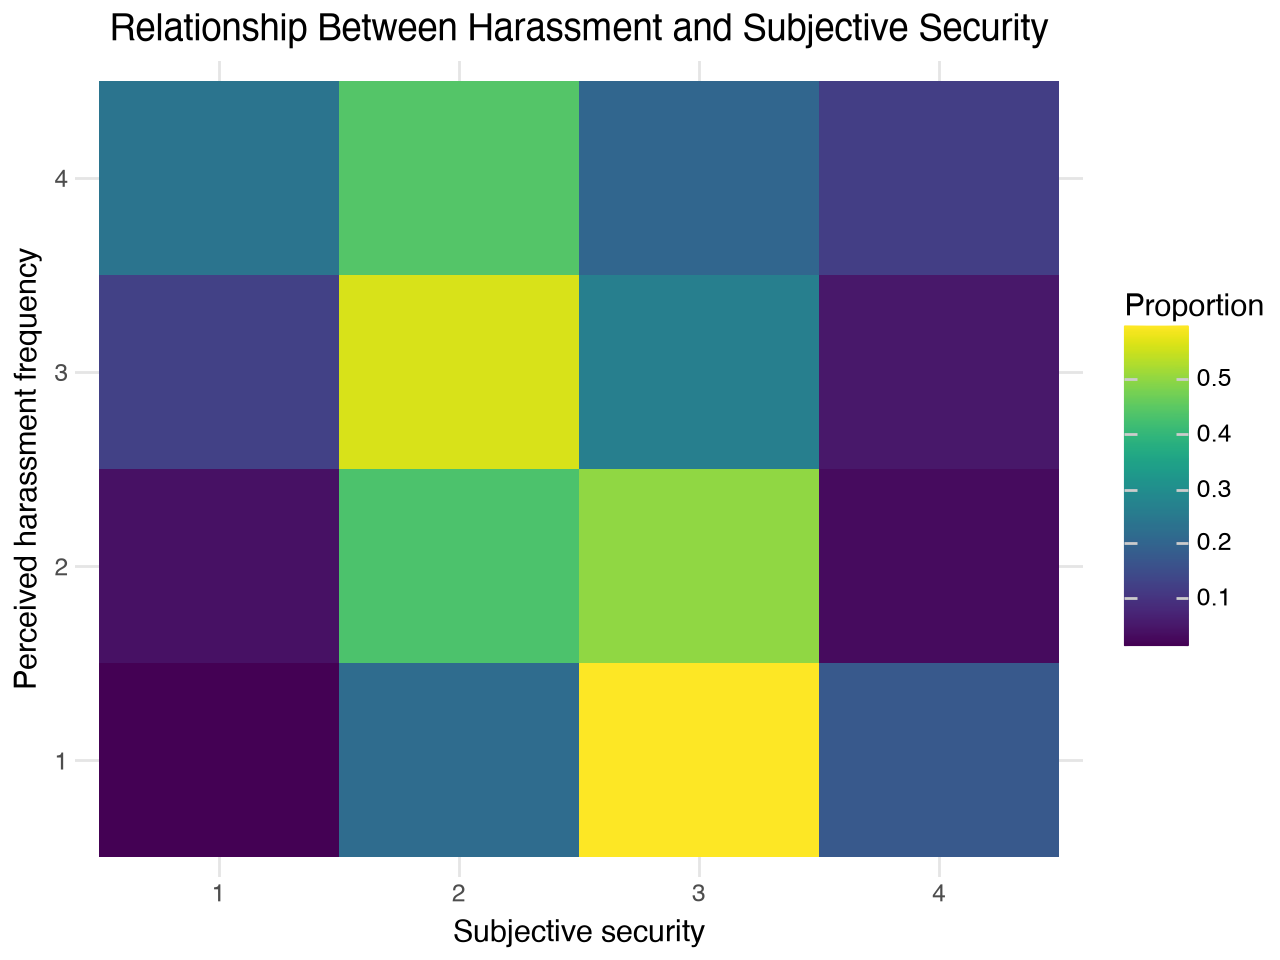

In [53]:
heat_df = (
    pd.crosstab(
        my1["harrassment_r"],
        my1["security_r"],
        normalize="index"
    )
    .reset_index()
    .melt(
        id_vars="harrassment_r",
        var_name="security_r",
        value_name="proportion"
    )
)

(
    ggplot(
        heat_df,
        aes(
            x="factor(security_r)",
            y="factor(harrassment_r)",
            fill="proportion"
        )
    )
    + geom_tile()
    + labs(
        title="Relationship Between Harassment and Subjective Security",
        x="Subjective security",
        y="Perceived harassment frequency",
        fill="Proportion"
    )
    + theme_minimal()
)

# Stacked bar chart

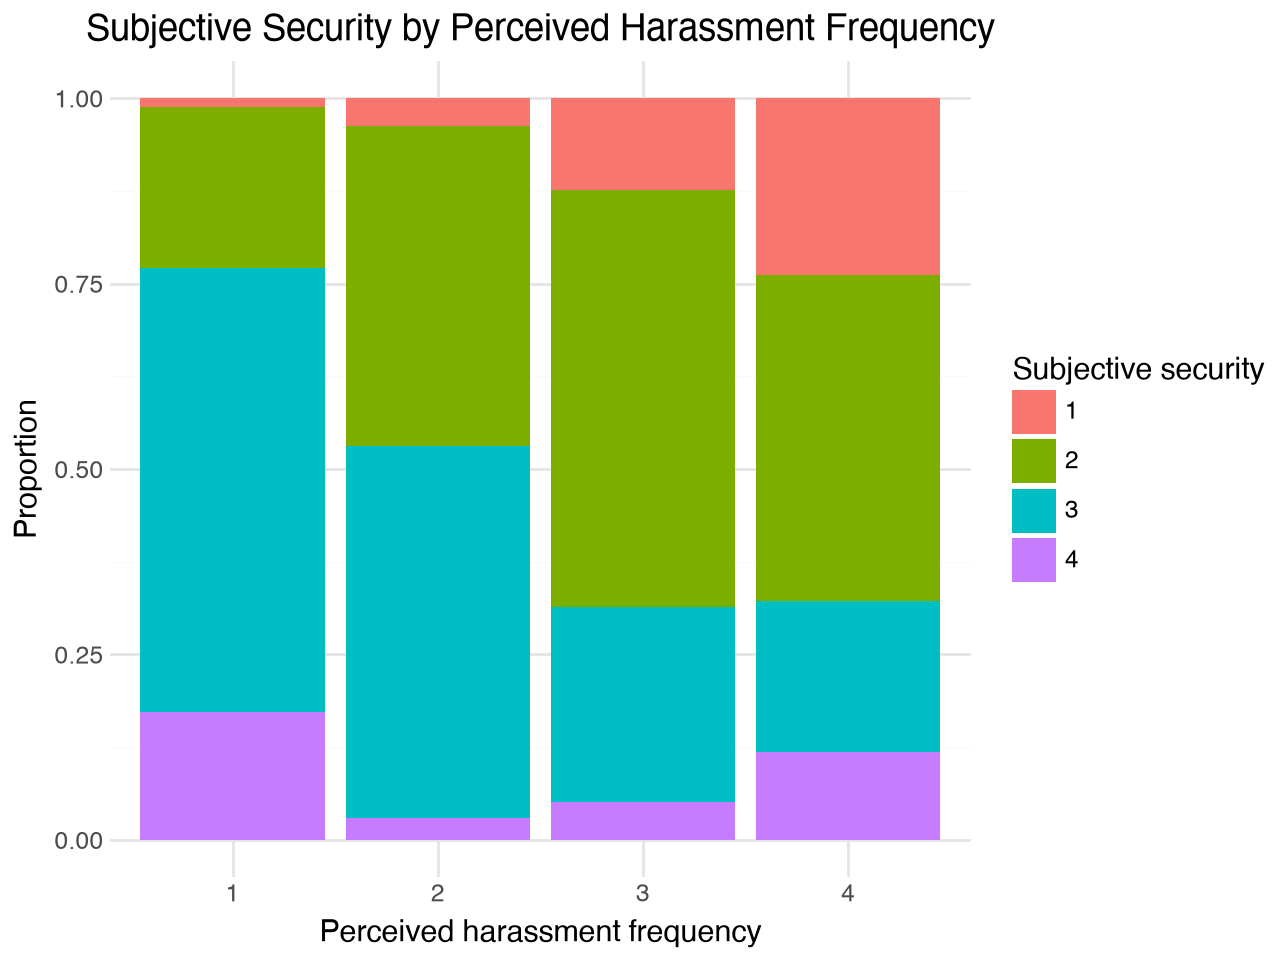

In [54]:
stacked_df = (
    pd.crosstab(
        my1["harrassment_r"],
        my1["security_r"],
        normalize="index"
    )
    .reset_index()
    .melt(
        id_vars="harrassment_r",
        var_name="security_r",
        value_name="proportion"
    )
)

(
    ggplot(
        stacked_df,
        aes(
            x="factor(harrassment_r)",
            y="proportion",
            fill="factor(security_r)"
        )
    )
    + geom_col(position="fill")
    + labs(
        title="Subjective Security by Perceived Harassment Frequency",
        x="Perceived harassment frequency",
        y="Proportion",
        fill="Subjective security"
    )
    + theme_minimal()
)

# Line chart to illustrate gender difference

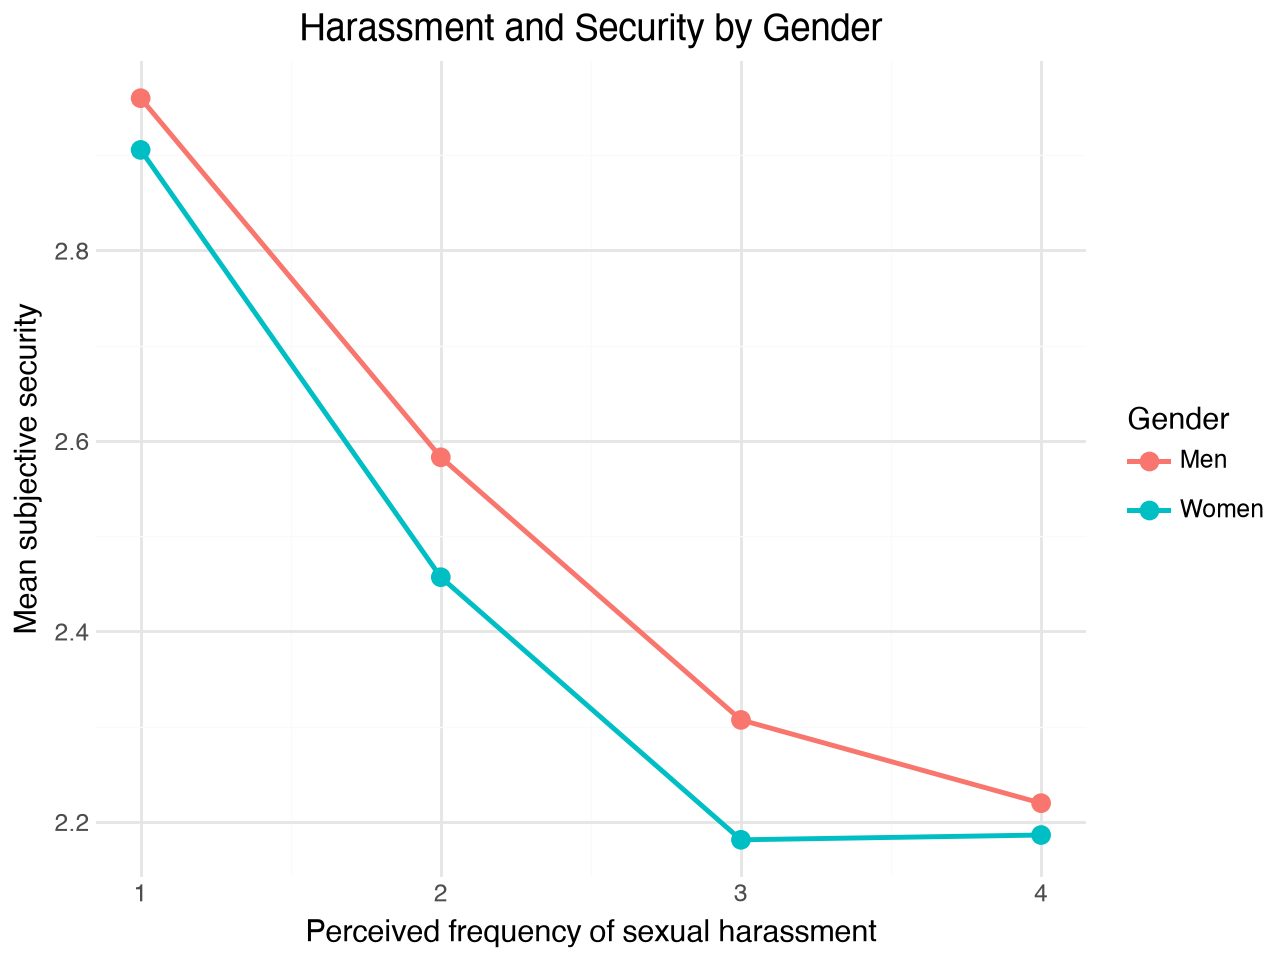

In [49]:
interaction_df = (
    my1.groupby(
        ["harrassment_r", "gender_bi"],
        observed=True
    )["security_r"]
    .mean()
    .reset_index()
)

interaction_df["Gender"] = interaction_df["gender_bi"].map({
    0: "Men",
    1: "Women"
})

(
    ggplot(
        interaction_df,
        aes(
            x="harrassment_r",
            y="security_r",
            color="Gender",
            group="Gender"
        )
    )
    + geom_point(size=3)
    + geom_line(size=1)
    + labs(
        title="Harassment and Security by Gender",
        x="Perceived frequency of sexual harassment",
        y="Mean subjective security",
        color="Gender"
    )
    + theme_minimal()
)